# Shallow-Squat — Training

The two-stage story: **CVCSPC self-supervised pretraining** (cross-view / cross-subject
pose-contrastive) then **fine-tuning** (3-seed), against a supervised baseline trained from
the same ImageNet init without SSL. Every curve regenerates from the frozen `results.pkl`
— no GPU. Shows SSL triplet-accuracy convergence, per-seed fine-tune vs baseline
convergence, and the SSL lift.

## Setup — load the frozen results

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

_CANDS = [Path(".planning/phases/07-image-based-errors-cvcspc/figures/results.pkl"),
          Path("../../.planning/phases/07-image-based-errors-cvcspc/figures/results.pkl")]
_PKL = next((p for p in _CANDS if p.exists()), None)
assert _PKL is not None, "results.pkl not found"
R = pickle.load(open(_PKL, "rb"))
print("Loaded:", _PKL)

FIG = Path("docs/figures") if Path("docs/figures").exists() else Path("../../docs/figures")
FIG.mkdir(parents=True, exist_ok=True)

SEEDS = sorted(R["seeds"])
print("SSL points:", len(R["ssl_triplet_acc"]),
      "| seeds:", SEEDS,
      "| fine-tune epochs:", {s: len(R["finetune_seeds"][s]) for s in SEEDS},
      "| baseline epochs:", {s: len(R["baseline_seeds"][s]) for s in SEEDS})

Loaded: ..\..\.planning\phases\07-image-based-errors-cvcspc\figures\results.pkl
SSL points: 20 | seeds: [7, 42, 1337] | fine-tune epochs: {7: 14, 42: 21, 1337: 22} | baseline epochs: {7: 24, 42: 19, 1337: 21}


## 1. CVCSPC SSL — triplet-accuracy convergence

The contrastive triplet accuracy (fraction of triplets with the positive closer than the
negative) climbs from ~0.75 to ~0.96 over pretraining, well above the 0.5 chance line — the
pose-contrastive objective is learning a separable representation. The peak epoch seeds the
fine-tune backbone.

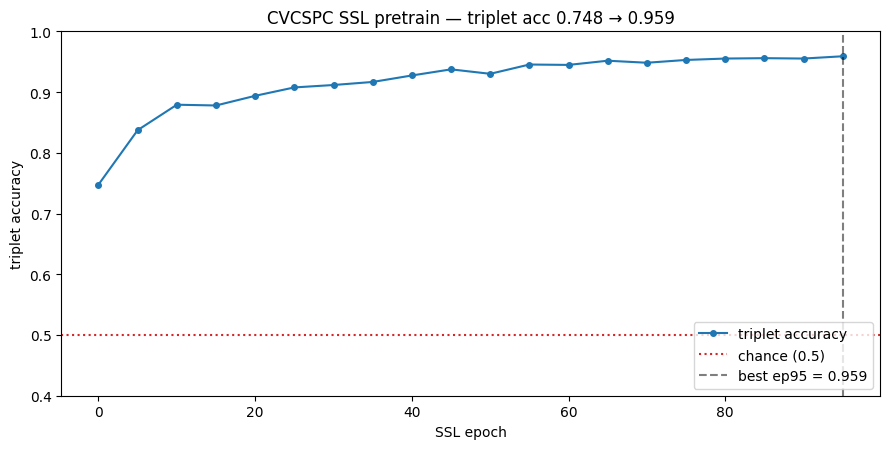

In [2]:
sa = R["ssl_triplet_acc"]
sep = [m["epoch"] for m in sa]
sac = [m["triplet_acc"] for m in sa]
best = int(np.argmax(sac))
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(sep, sac, "C0-o", ms=4, label="triplet accuracy")
ax.axhline(0.5, color="C3", ls=":", label="chance (0.5)")
ax.axvline(sep[best], color="k", ls="--", alpha=0.5,
           label=f"best ep{sep[best]} = {sac[best]:.3f}")
ax.set_xlabel("SSL epoch")
ax.set_ylabel("triplet accuracy")
ax.set_ylim(0.4, 1.0)
ax.set_title(f"CVCSPC SSL pretrain — triplet acc {sac[0]:.3f} → {sac[-1]:.3f}")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

## 2. Per-seed fine-tune vs baseline — loss + val-F1

For each seed: train/val loss (left axis) and val-F1 (right axis) over epochs, CVCSPC
fine-tune vs the supervised baseline. The CVCSPC runs start from a stronger init (lower
epoch-0 train loss, higher early val-F1) and the gap persists; early-stop selects the
pre-overfit peak as `best.pt`.

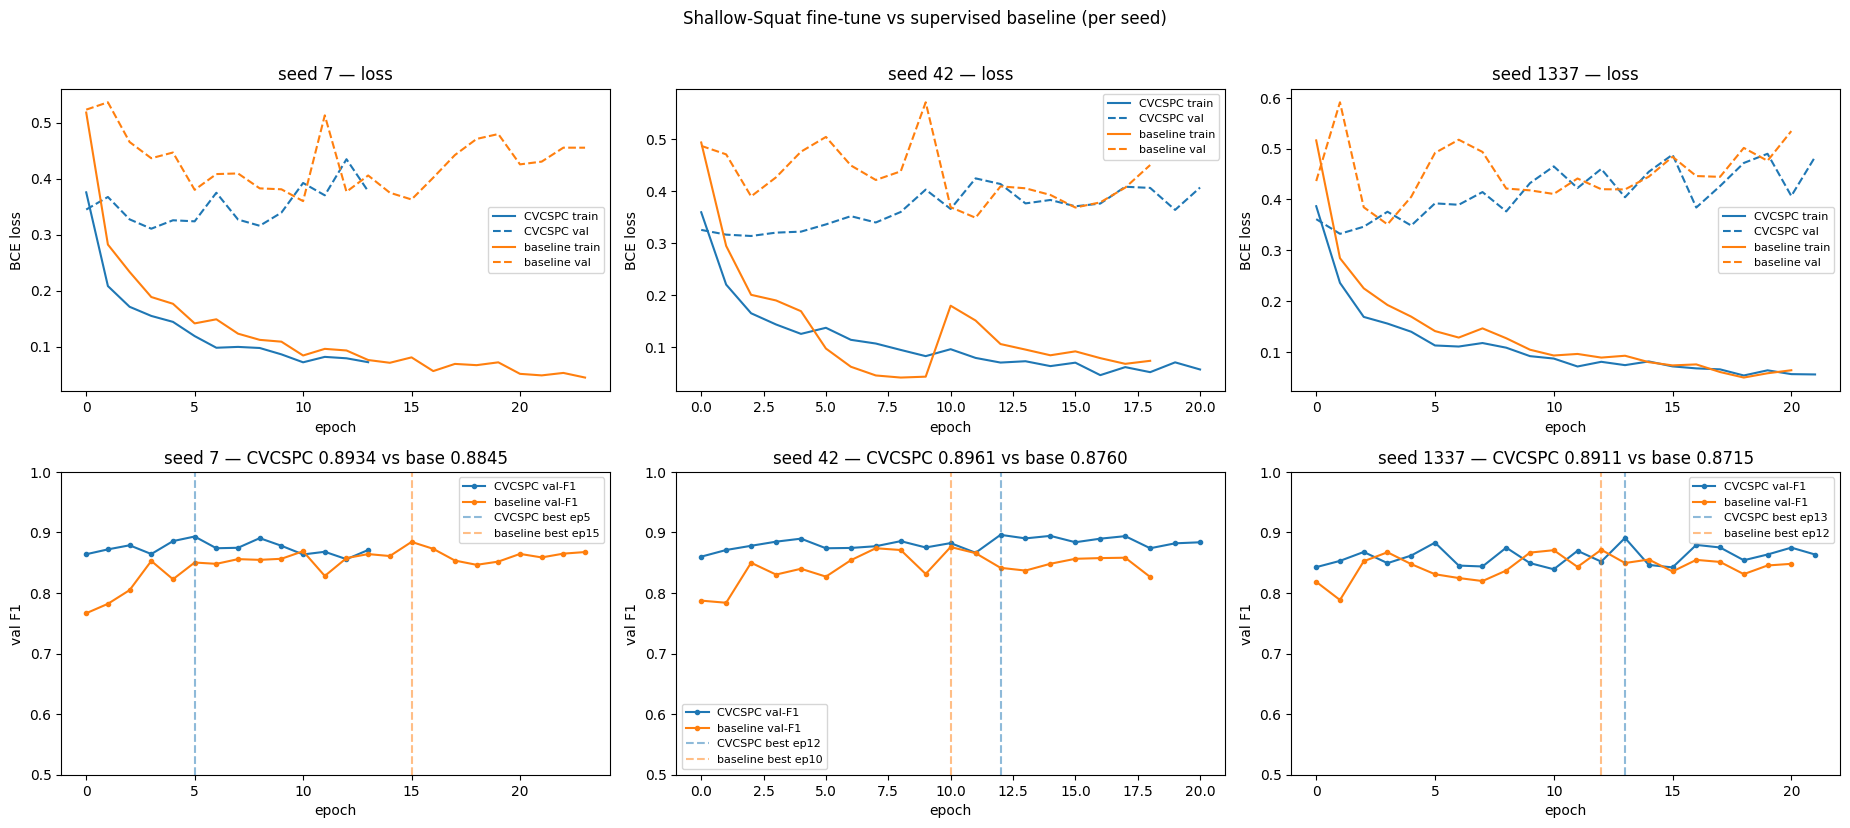

In [3]:
fig, axes = plt.subplots(2, len(SEEDS), figsize=(6.2 * len(SEEDS), 8.4), squeeze=False)
for j, s in enumerate(SEEDS):
    fh = R["finetune_seeds"][s]
    bh = R["baseline_seeds"][s]
    fe = [m["epoch"] for m in fh]
    be = [m["epoch"] for m in bh]

    axl = axes[0][j]
    axl.plot(fe, [m["train_loss_mean"] for m in fh], "C0-", label="CVCSPC train")
    axl.plot(fe, [m["val_loss_mean"] for m in fh], "C0--", label="CVCSPC val")
    axl.plot(be, [m["train_loss_mean"] for m in bh], "C1-", label="baseline train")
    axl.plot(be, [m["val_loss_mean"] for m in bh], "C1--", label="baseline val")
    axl.set_xlabel("epoch")
    axl.set_ylabel("BCE loss")
    axl.set_title(f"seed {s} — loss")
    axl.legend(fontsize=8)

    axf = axes[1][j]
    ff = [m["val_f1"] for m in fh]
    bf = [m["val_f1"] for m in bh]
    fb = int(np.argmax(ff))
    bb = int(np.argmax(bf))
    axf.plot(fe, ff, "C0-o", ms=3, label="CVCSPC val-F1")
    axf.plot(be, bf, "C1-o", ms=3, label="baseline val-F1")
    axf.axvline(fe[fb], color="C0", ls="--", alpha=0.5, label=f"CVCSPC best ep{fe[fb]}")
    axf.axvline(be[bb], color="C1", ls="--", alpha=0.5, label=f"baseline best ep{be[bb]}")
    axf.set_xlabel("epoch")
    axf.set_ylabel("val F1")
    axf.set_ylim(0.5, 1.0)
    axf.set_title(f"seed {s} — CVCSPC {ff[fb]:.4f} vs base {bf[bb]:.4f}")
    axf.legend(fontsize=8)
fig.suptitle("Shallow-Squat fine-tune vs supervised baseline (per seed)", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

## 3. SSL triplet-accuracy + the baseline → CVCSPC lift

The delivered multi-panel figure: SSL convergence, the per-seed val-F1 peaks (baseline vs
CVCSPC), and the test-F1 lift. The CVCSPC ensemble lands at 0.8902 test-F1 vs the supervised
baseline's 0.875 — an SSL lift of +0.0152 on the official test split.

supervised baseline test-F1 : 0.8750
CVCSPC ensemble test-F1     : 0.8902
SSL lift                    : +0.0152


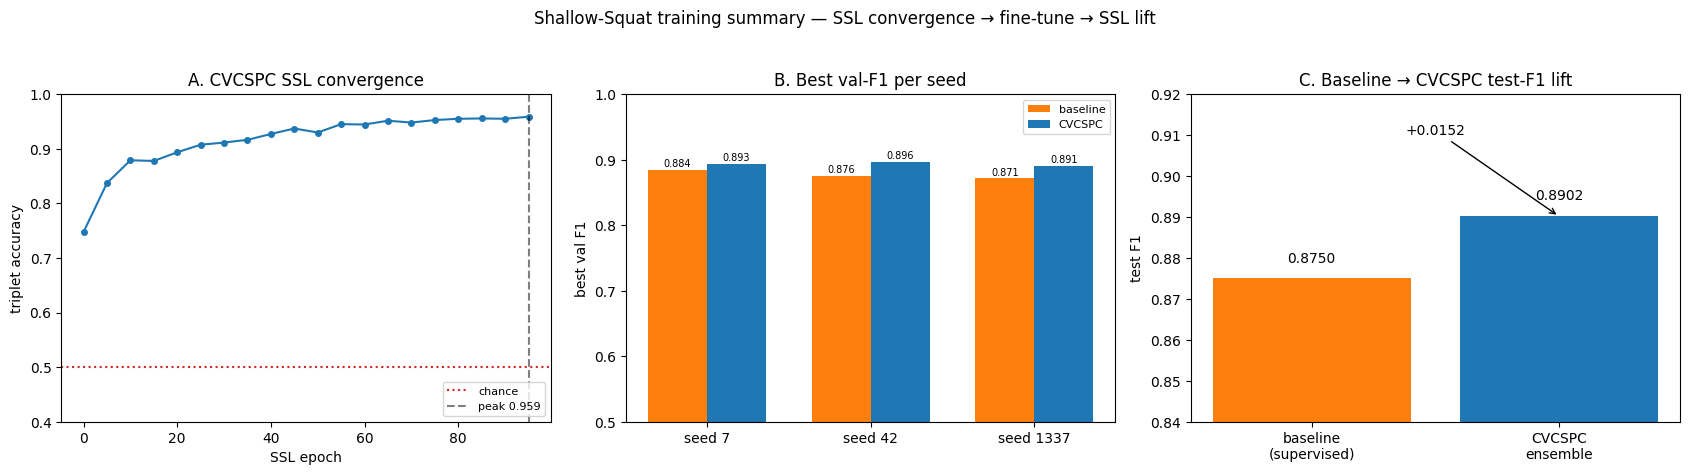

In [4]:
base_test = R["baseline_control"]["test_f1"]
cvc_test = R["test_f1"]["cvcspc_ensemble"]
lift = R["ssl_lift"]
print(f"supervised baseline test-F1 : {base_test:.4f}")
print(f"CVCSPC ensemble test-F1     : {cvc_test:.4f}")
print(f"SSL lift                    : {lift:+.4f}")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))

# Panel A: SSL convergence
ax[0].plot(sep, sac, "C0-o", ms=4)
ax[0].axhline(0.5, color="C3", ls=":", label="chance")
ax[0].axvline(sep[best], color="k", ls="--", alpha=0.5, label=f"peak {sac[best]:.3f}")
ax[0].set_xlabel("SSL epoch")
ax[0].set_ylabel("triplet accuracy")
ax[0].set_ylim(0.4, 1.0)
ax[0].set_title("A. CVCSPC SSL convergence")
ax[0].legend(loc="lower right", fontsize=8)

# Panel B: per-seed best val-F1, baseline vs CVCSPC
x = np.arange(len(SEEDS))
w = 0.36
b_best = [max(m["val_f1"] for m in R["baseline_seeds"][s]) for s in SEEDS]
c_best = [max(m["val_f1"] for m in R["finetune_seeds"][s]) for s in SEEDS]
bb = ax[1].bar(x - w / 2, b_best, w, color="C1", label="baseline")
cb = ax[1].bar(x + w / 2, c_best, w, color="C0", label="CVCSPC")
for bar in list(bb) + list(cb):
    ax[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
               f"{bar.get_height():.3f}", ha="center", fontsize=7)
ax[1].set_xticks(x)
ax[1].set_xticklabels([f"seed {s}" for s in SEEDS])
ax[1].set_ylabel("best val F1")
ax[1].set_ylim(0.5, 1.0)
ax[1].set_title("B. Best val-F1 per seed")
ax[1].legend(fontsize=8)

# Panel C: test-F1 lift baseline -> CVCSPC ensemble
cb2 = ax[2].bar(["baseline\n(supervised)", "CVCSPC\nensemble"], [base_test, cvc_test],
                color=["C1", "C0"])
for bar, v in zip(cb2, [base_test, cvc_test]):
    ax[2].text(bar.get_x() + bar.get_width() / 2, v + 0.004, f"{v:.4f}", ha="center")
ax[2].annotate(f"+{lift:.4f}", xy=(1, cvc_test), xytext=(0.5, cvc_test + 0.02),
               ha="center", fontsize=10,
               arrowprops=dict(arrowstyle="->", color="k"))
ax[2].set_ylabel("test F1")
ax[2].set_ylim(0.84, 0.92)
ax[2].set_title("C. Baseline → CVCSPC test-F1 lift")
fig.suptitle("Shallow-Squat training summary — SSL convergence → fine-tune → SSL lift",
             fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.savefig(FIG / "shallow_squat_training_curves.png", dpi=130, bbox_inches="tight")
plt.show()

## Notes
- All curves from `results.pkl` — reproducible without GPU.
- 3-seed runs (42 / 1337 / 7); ensemble is the mean per-crop sigmoid score.
- SSL loss deviation: pretrained with the 3-term code loss; the paper's Eq.1 is 2-term
  (see `loss_deviation_note` in the evaluation notebook).